<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap4_diffusionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

４章 拡散モデル

本章ではテキストで内容を指示するだけで画像を生成できるモデルの仕組みを掘り下げていく。

拡散モデルの基本的な考え方は、ノイズを加えて劣化させた画像を受け取り、そのノイズを取り除いて元の鮮明な画像に復元すること。

In [1]:
%pip install genaibook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.7 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: huggingface_hub
    Found ex

4.1 重要な着想：反復的精緻化

拡散モデルを強力にしている要素は、GAN や VAE が最終出力を１発勝負で出力するのに対して、拡散モデルは他段階の反復を経て出力を生成する。この反復的精緻化（iterative refinement）のおかげで徐々に出力の質を高めていくことができる。


Hugging face の diffuser ライブラリを使えば事前訓練済みの拡散モデルを簡単にロードできる。ここでは初期の拡散モデルの一つである ddpm-celebahq-256 のデータセットを使って、これににた画像を生成する。

In [5]:
import torch
from diffusers import DDPMPipeline

from genaibook.core import get_device

# GPU と CPU のどっちを使うかを設定する
device = get_device()

# パイプラインを読み込む
image_pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
image_pipe.to(device)

# 画像をサンプリングする
# image_pipe().images[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

コードを実行すると、画像生成までに１０００ステップも要していることがわかる。
これが拡散モデルの欠点の一つ。
このサンプリングプロセスをステップごとに再現すれば、内部で何が起きているのかをより深く理解できる。

拡散プロセスの開始時、サンプルxを４枚分のランダム画像で初期化して、ここから３０ステップかけて入力画像のノイズを除去し、最終的に実データの画像に近づけていく。

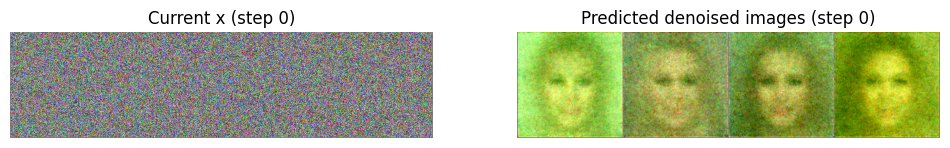

In [ ]:
from genaibook.core import plot_noise_and_denoise

# ランダムな初期値として４枚の画像バッチを用いる
# 各画像は３チャネル（RGB）、256*256ピクセルの画像
image = torch.randn(4, 3, 256, 256).to(device)

# 拡散ステップ数を指定する
image_pipe.scheduler.set_timesteps(num_inference_steps=30)

# サンプリングのタイムステップを繰り返す
for i, t in enumerate(image_pipe.scheduler.timesteps):
  with torch.inference_mode():
    noise_pred = image_pipe.unet(image, t)["sample"]

    scheduler_output = image_pipe.scheduler.step(noise_pred, t, image)

    image = scheduler_output.prev_sample

    if i % 10 == 0 or i == len(image_pipe.scheduler.timesteps) - 1:
      plot_noise_and_denoise(scheduler_output, i)